# Beadandó ábrák létrehozása

Ez a notebook a cukorbetegség-előrejelzési beadandóhoz készít beszúrható ábrákat. Ugyanazt a szivárgásmentes logikát használja, mint a modellezési notebookok: a nyers `diabetes.csv` adaton dolgozik, a problémás nulla értékeket pipeline-on belül mediánnal helyettesíti, majd a korábban kiválasztott legjobb modelleket tanítja újra a tanítóhalmazon.

Az ábrák a `figures/` mappába kerülnek PNG formátumban.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
raw_data = pd.read_csv("diabetes.csv")
raw_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

class ZeroToMedianImputer(BaseEstimator, TransformerMixin):
    """Replace invalid zeros in selected columns with training medians."""

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = X.columns.to_numpy()
        self.medians_ = {}

        for column in self.columns:
            non_zero_values = X.loc[X[column] != 0, column]
            self.medians_[column] = non_zero_values.median()

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).copy()

        for column, median in self.medians_.items():
            X[column] = X[column].replace(0, median)

        return X

X = raw_data.drop(columns="Outcome")
y = raw_data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (614, 8) Test: (154, 8)


## 1. Adatminőségi és célváltozó-ábrák

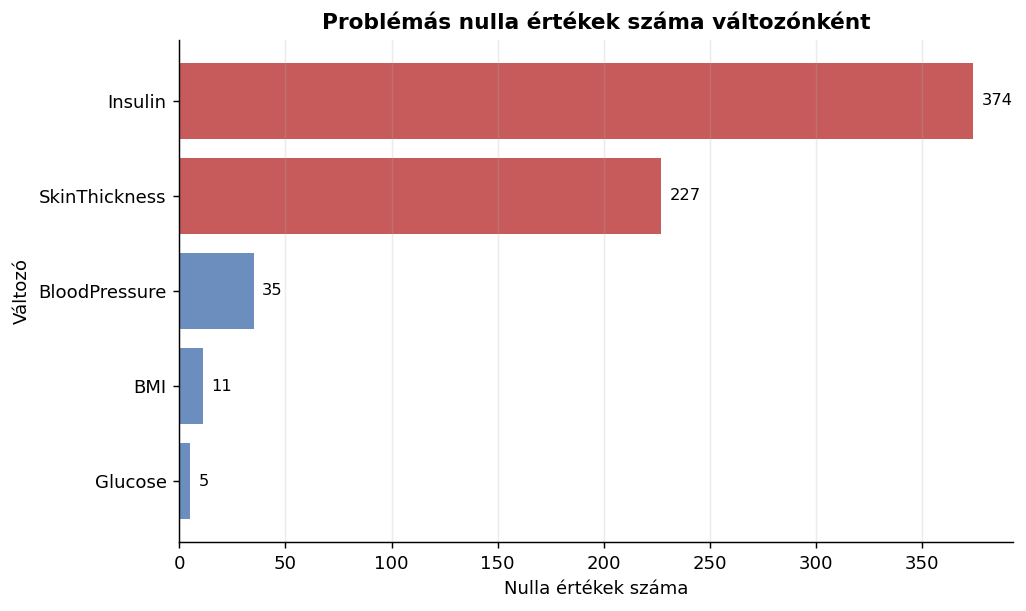

In [4]:
zero_counts = raw_data[zero_as_missing_columns].eq(0).sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = ["#6c8ebf" if value < 100 else "#c75b5b" for value in zero_counts]
ax.barh(zero_counts.index, zero_counts.values, color=colors)
ax.set_title("Problémás nulla értékek száma változónként", fontweight="bold")
ax.set_xlabel("Nulla értékek száma")
ax.set_ylabel("Változó")
ax.grid(axis="x", alpha=0.25)
for i, value in enumerate(zero_counts.values):
    ax.text(value + 4, i, str(value), va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_problematic_zero_values.png", bbox_inches="tight")
plt.show()

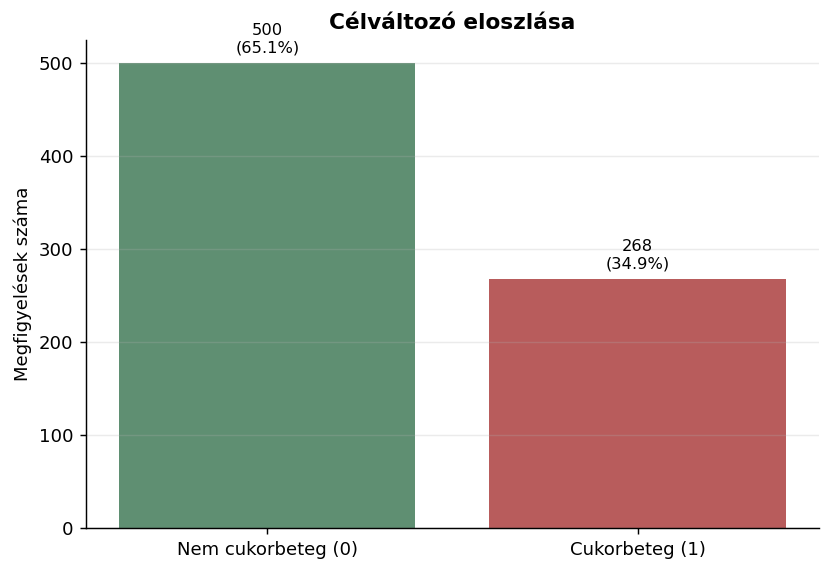

In [5]:
class_counts = y.value_counts().sort_index()
labels = ["Nem cukorbeteg (0)", "Cukorbeteg (1)"]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(labels, class_counts.values, color=["#5f8f72", "#b85c5c"])
ax.set_title("Célváltozó eloszlása", fontweight="bold")
ax.set_ylabel("Megfigyelések száma")
ax.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 8, f"{value}\n({value / len(y):.1%})", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_target_distribution.png", bbox_inches="tight")
plt.show()

## 2. A legjobb modellek újratanítása

Az alábbi modellek a korábbi keresztvalidációs notebookokban kiválasztott legjobb hiperparamétereket használják. Itt már nem új grid search fut, hanem az ábrákhoz szükséges végső modellek tanítása.

In [6]:
models = {
    "Logisztikus regresszió": Pipeline([
        ("zero_imputer", ZeroToMedianImputer(columns=zero_as_missing_columns)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.31622776601683794,
            class_weight="balanced",
            l1_ratio=0.1,
            max_iter=10_000,
            penalty="elasticnet",
            random_state=RANDOM_STATE,
            solver="saga",
        )),
    ]),
    "Random Forest": Pipeline([
        ("zero_imputer", ZeroToMedianImputer(columns=zero_as_missing_columns)),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            max_depth=4,
            max_features="sqrt",
            min_samples_leaf=1,
            n_estimators=500,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost": Pipeline([
        ("zero_imputer", ZeroToMedianImputer(columns=zero_as_missing_columns)),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            colsample_bytree=0.8,
            learning_rate=0.1,
            max_depth=2,
            n_estimators=50,
            reg_lambda=5,
            scale_pos_weight=1,
            subsample=0.8,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("zero_imputer", ZeroToMedianImputer(columns=zero_as_missing_columns)),
        ("model", GradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=1,
            max_features="sqrt",
            min_samples_leaf=3,
            n_estimators=200,
            random_state=RANDOM_STATE,
            subsample=0.8,
        )),
    ]),
}

probabilities = {}
thresholds = {}
metrics_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    probabilities[name] = y_test_proba

    precision, recall, threshold_values = precision_recall_curve(y_train, y_train_proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_threshold = threshold_values[np.argmax(f1_scores[:-1])]
    thresholds[name] = best_threshold

    y_pred = (y_test_proba >= best_threshold).astype(int)
    metrics_rows.append({
        "Modell": name,
        "Teszt ROC AUC": roc_auc_score(y_test, y_test_proba),
        "Teszt accuracy": accuracy_score(y_test, y_pred),
        "Teszt F1": f1_score(y_test, y_pred),
        "F1-küszöb": best_threshold,
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,Modell,Teszt ROC AUC,Teszt accuracy,Teszt F1,F1-küszöb
0,Logisztikus regresszió,0.811481,0.720779,0.605505,0.563438
1,Random Forest,0.819444,0.746753,0.666667,0.508217
2,XGBoost,0.816296,0.727273,0.666667,0.333893
3,Gradient Boosting,0.818519,0.740260,0.677419,0.320239


## 3. Modell-összehasonlító ábrák

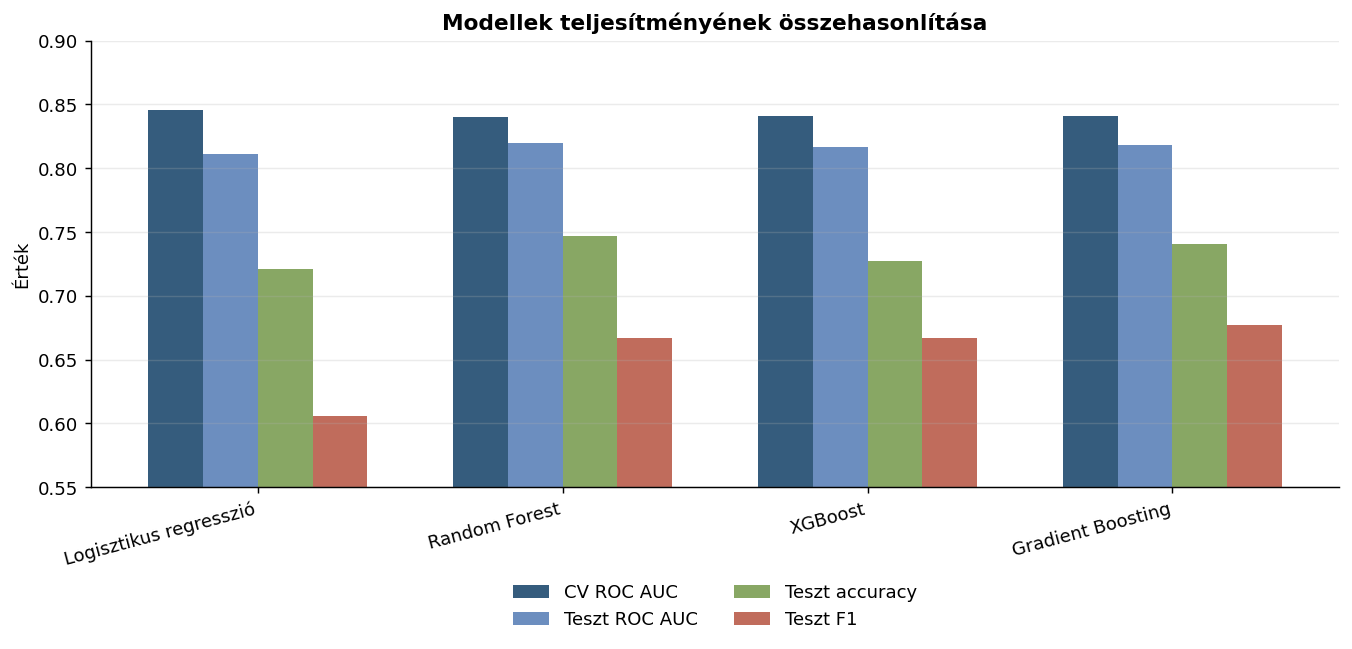

In [7]:
cv_scores = {
    "Logisztikus regresszió": 0.8455,
    "Random Forest": 0.8402,
    "XGBoost": 0.8409,
    "Gradient Boosting": 0.8407,
}

plot_df = metrics_df.copy()
plot_df["CV ROC AUC"] = plot_df["Modell"].map(cv_scores)
plot_df = plot_df[["Modell", "CV ROC AUC", "Teszt ROC AUC", "Teszt accuracy", "Teszt F1"]]

long_df = plot_df.melt(id_vars="Modell", var_name="Mutató", value_name="Érték")
model_order = ["Logisztikus regresszió", "Random Forest", "XGBoost", "Gradient Boosting"]
metric_order = ["CV ROC AUC", "Teszt ROC AUC", "Teszt accuracy", "Teszt F1"]

x = np.arange(len(model_order))
width = 0.18
palette = ["#355c7d", "#6c8ebf", "#88a764", "#c06c5c"]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
for idx, metric in enumerate(metric_order):
    values = [plot_df.loc[plot_df["Modell"] == model, metric].iloc[0] for model in model_order]
    ax.bar(x + (idx - 1.5) * width, values, width, label=metric, color=palette[idx])

ax.set_title("Modellek teljesítményének összehasonlítása", fontweight="bold")
ax.set_ylabel("Érték")
ax.set_ylim(0.55, 0.90)
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncols=2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_model_metric_comparison.png", bbox_inches="tight")
plt.show()

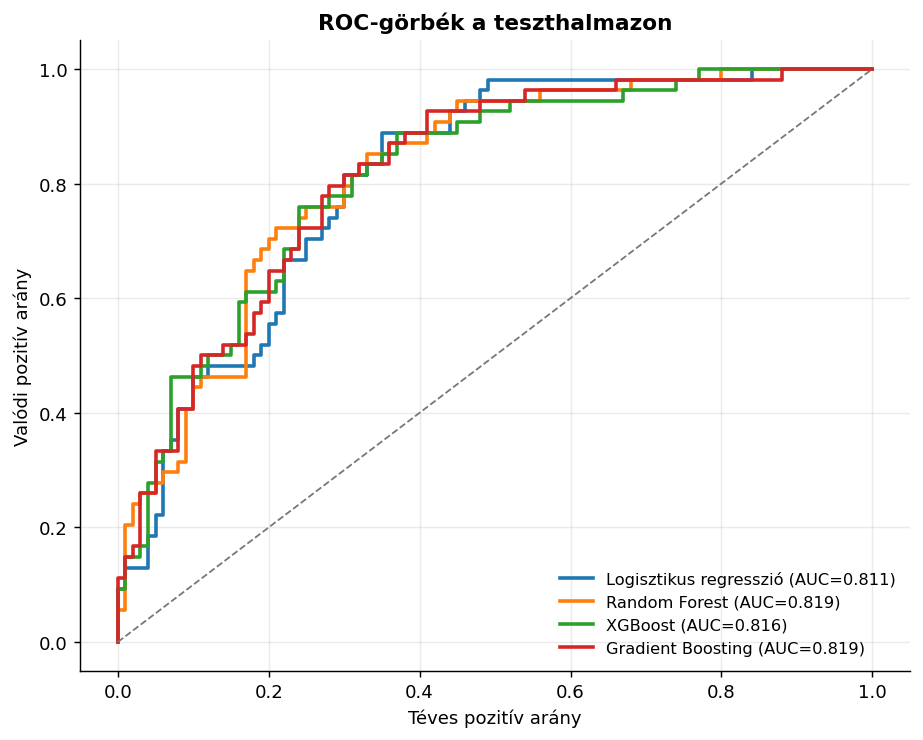

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 5.8))
for name, y_test_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    auc_value = roc_auc_score(y_test, y_test_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_value:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="#777777", linewidth=1)
ax.set_title("ROC-görbék a teszthalmazon", fontweight="bold")
ax.set_xlabel("Téves pozitív arány")
ax.set_ylabel("Valódi pozitív arány")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_test_roc_curves.png", bbox_inches="tight")
plt.show()

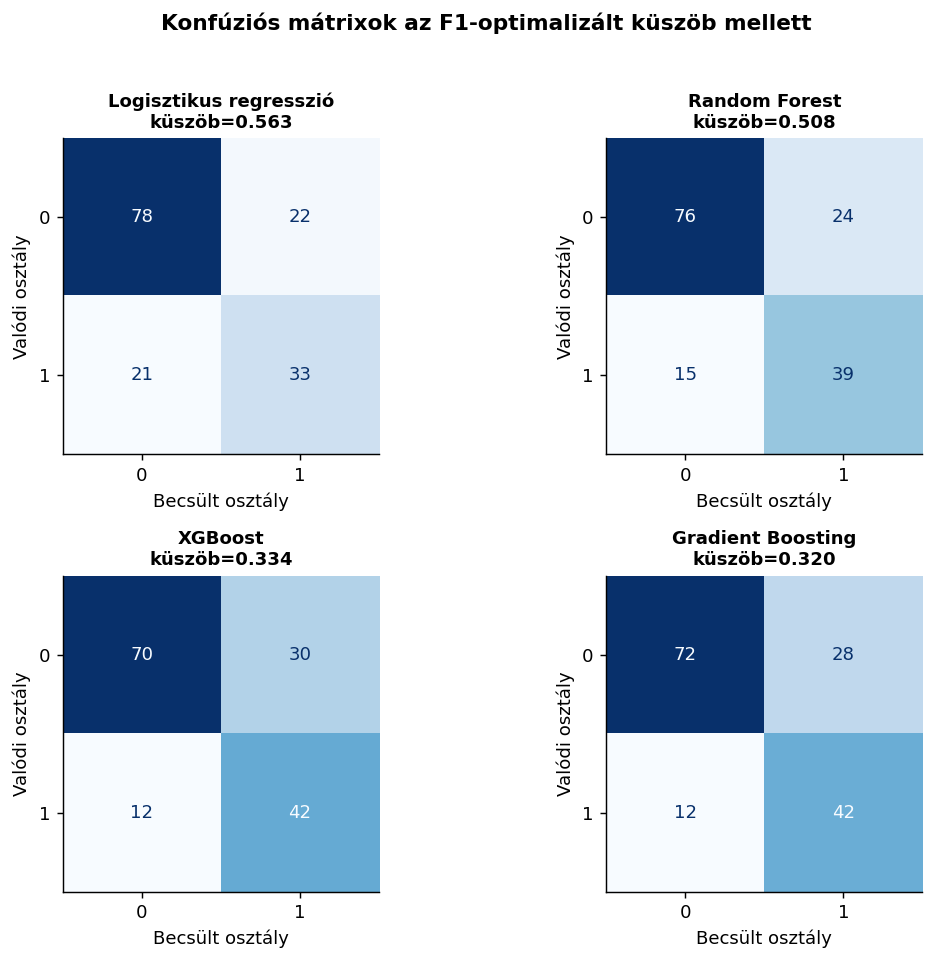

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(8.8, 7.2))
axes = axes.ravel()

for ax, (name, y_test_proba) in zip(axes, probabilities.items()):
    y_pred = (y_test_proba >= thresholds[name]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(f"{name}\nküszöb={thresholds[name]:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Becsült osztály")
    ax.set_ylabel("Valódi osztály")

fig.suptitle("Konfúziós mátrixok az F1-optimalizált küszöb mellett", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 4. Magyarázhatósági ábrák

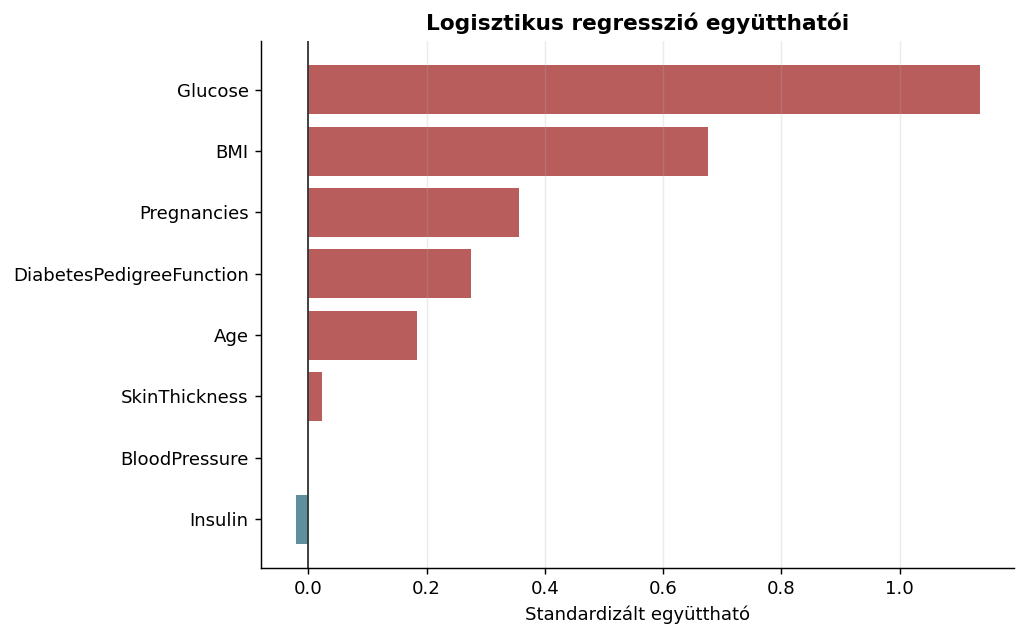

In [10]:
logreg = models["Logisztikus regresszió"].named_steps["model"]
coef_df = pd.DataFrame({
    "Változó": X.columns,
    "Együttható": logreg.coef_.ravel(),
}).sort_values("Együttható")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#b85c5c" if value > 0 else "#5f8f9d" for value in coef_df["Együttható"]]
ax.barh(coef_df["Változó"], coef_df["Együttható"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Logisztikus regresszió együtthatói", fontweight="bold")
ax.set_xlabel("Standardizált együttható")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_logistic_regression_coefficients.png", bbox_inches="tight")
plt.show()

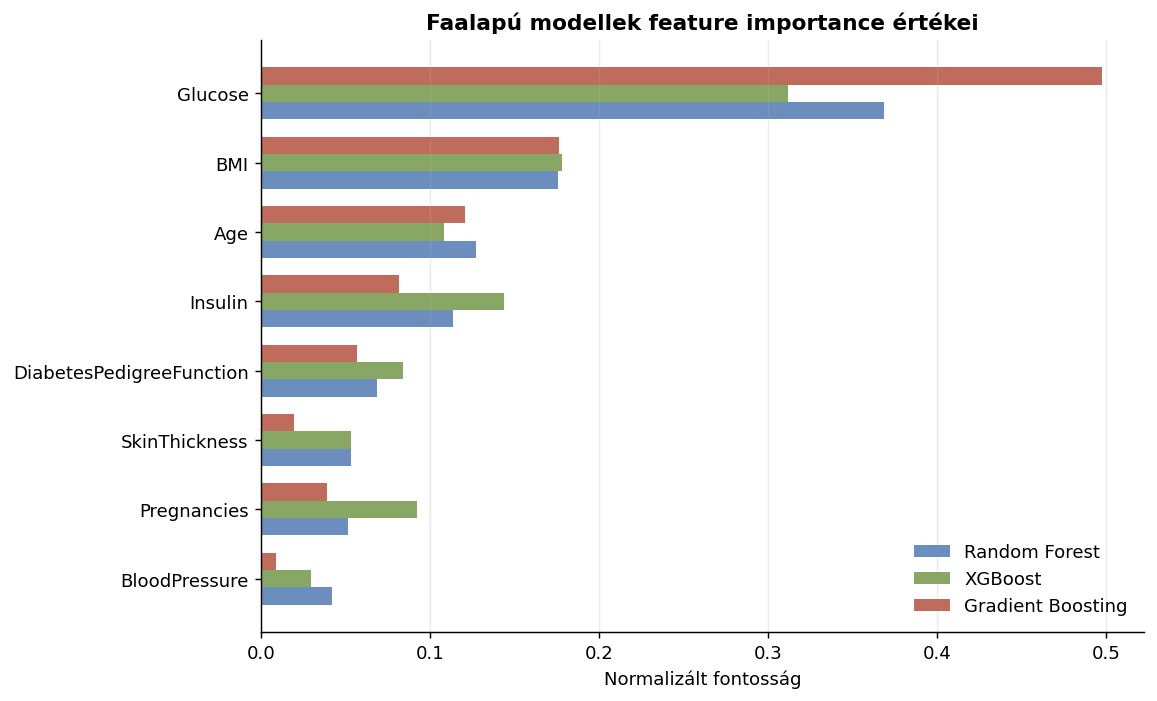

In [11]:
importance_frames = []
for name in ["Random Forest", "XGBoost", "Gradient Boosting"]:
    fitted = models[name].named_steps["model"]
    imp = pd.Series(fitted.feature_importances_, index=X.columns)
    imp = imp / imp.sum()
    importance_frames.append(imp.rename(name))

importance_df = pd.concat(importance_frames, axis=1).sort_values("Random Forest", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
y_pos = np.arange(len(importance_df.index))
width = 0.25
for idx, col in enumerate(importance_df.columns):
    ax.barh(y_pos + (idx - 1) * width, importance_df[col], height=width, label=col, color=palette[idx + 1])

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df.index)
ax.set_title("Faalapú modellek feature importance értékei", fontweight="bold")
ax.set_xlabel("Normalizált fontosság")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_tree_model_feature_importance.png", bbox_inches="tight")
plt.show()

In [12]:
print("Elkészült ábrák:")
for file in sorted(FIGURE_DIR.glob("*.png")):
    print(file)

Elkészült ábrák:
figures/01_problematic_zero_values.png
figures/02_target_distribution.png
figures/03_model_metric_comparison.png
figures/04_test_roc_curves.png
figures/05_confusion_matrices.png
figures/06_logistic_regression_coefficients.png
figures/07_tree_model_feature_importance.png
